In [305]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [306]:
payments = pd.read_csv('payments.csv')
payments.head()

,id_user,training_type,sum_payment,date
0,1000,indiv,1800.0,2023-03-04
1,1000,indiv,1800.0,2023-03-21
2,1000,indiv,1800.0,2023-04-03
3,1000,indiv,1800.0,2023-04-12
4,1000,indiv,1800.0,2023-04-20


### Задача 1. EDA

In [307]:
payments.shape

(35775, 4)

In [308]:
payments.dtypes

id_user            int64
training_type     object
sum_payment      float64
date              object
dtype: object

In [309]:
payments.isnull().sum()

id_user            0
training_type      0
sum_payment      715
date             357
dtype: int64

In [310]:
payments[payments['sum_payment'].isnull()]

,id_user,training_type,sum_payment,date
18,1000,indiv,NaN,2023-08-09
32,1000,indiv,NaN,2023-12-21
54,1001,group,NaN,2023-02-07
89,1001,indiv,NaN,2023-04-30
118,1001,group,NaN,2023-07-22
...,...,...,...,...
35488,1987,indiv,NaN,2023-06-01
35520,1988,indiv,NaN,2023-03-16
35643,1993,group,NaN,2023-08-06
35691,1995,group,NaN,2023-11-23


In [311]:
# заполним пропуски для платежей, зная цену для каждого тарифа
payments.loc[(payments['sum_payment'].isnull()) & (payments['training_type'] == 'group'), 'sum_payment'] = 800
payments.loc[(payments['sum_payment'].isnull()) & (payments['training_type'] == 'indiv'), 'sum_payment'] = 1800

In [312]:
#приведем date к дате 
payments['date'] = pd.to_datetime(payments['date'], errors = 'coerce')

In [313]:
payments.isnull().sum()

id_user            0
training_type      0
sum_payment        0
date             357
dtype: int64

In [314]:
# заполним пропуски, учитывая измененный тариф для мая 
payments.loc[(payments['sum_payment'].isnull()) & (payments['training_type'] == 'indiv') &\
             (payments['date'].dt.month == 5), 'sum_payment'] = 1600

In [315]:
payments.isnull().sum()

id_user            0
training_type      0
sum_payment        0
date             357
dtype: int64

In [316]:
payments = payments[~payments['date'].isnull()]

In [317]:
payments.isnull().sum()

id_user          0
training_type    0
sum_payment      0
date             0
dtype: int64

In [318]:
payments['sum_payment'].describe()

count    35418.000000
mean      1116.398441
std        874.529319
min        800.000000
25%        800.000000
50%        800.000000
75%       1600.000000
max      18000.000000
Name: sum_payment, dtype: float64

In [319]:
payments['training_type'].value_counts(normalize=True)

training_type
group    0.729318
indiv    0.270682
Name: proportion, dtype: float64

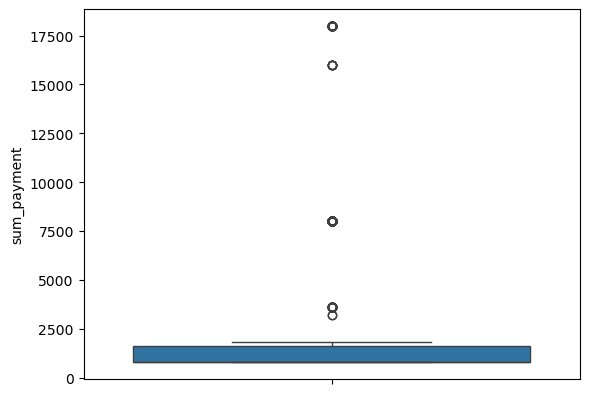

In [320]:
sns.boxplot(payments['sum_payment'])
plt.show()

In [321]:
#избавимся от выбросов 
Q1 = np.percentile(payments['sum_payment'],25)
Q3 = np.percentile(payments['sum_payment'],75)
IQR = Q3-Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

In [322]:
payments_clean = payments[payments['sum_payment'] < upper_bound].copy()
payments_clean.head()

,id_user,training_type,sum_payment,date
0,1000,indiv,1800.0,2023-03-04
1,1000,indiv,1800.0,2023-03-21
2,1000,indiv,1800.0,2023-04-03
3,1000,indiv,1800.0,2023-04-12
4,1000,indiv,1800.0,2023-04-20


### Задача 2. Агрегация данных

In [323]:
payments_clean['mon'] = payments_clean['date'].dt.strftime('%Y-%m')
payments_clean.head()

,id_user,training_type,sum_payment,date,mon
0,1000,indiv,1800.0,2023-03-04,2023-03
1,1000,indiv,1800.0,2023-03-21,2023-03
2,1000,indiv,1800.0,2023-04-03,2023-04
3,1000,indiv,1800.0,2023-04-12,2023-04
4,1000,indiv,1800.0,2023-04-20,2023-04


In [324]:
pivot_pay = pd.pivot_table(payments_clean,values = 'sum_payment',index = ['id_user','mon'],\
                           columns = 'training_type', aggfunc = ['count','sum'], fill_value = 0).reset_index()
pivot_pay

id_user      mon count           sum        
training_type                  group indiv   group   indiv
0                1000  2023-03     0     2     0.0  3600.0
1                1000  2023-04     0     4     0.0  7200.0
2                1000  2023-05     0     4     0.0  6400.0
3                1000  2023-06     0     2     0.0  3600.0
4                1000  2023-07     0     4     0.0  7200.0
...               ...      ...   ...   ...     ...     ...
5288             1998  2023-03     2     0  1600.0     0.0
5289             1998  2023-04     6     0  4800.0     0.0
5290             1998  2023-05     4     0  3200.0     0.0
5291             1998  2023-06     6     0  4800.0     0.0
5292             1998  2023-07     4     0  3200.0     0.0

[5293 rows x 6 columns]

In [325]:
pivot_pay.columns = ['id_user','mon','cnt_group','cnt_indiv','sum_group','sum_indiv']
pivot_pay['cnt_total'] = pivot_pay['cnt_group']+pivot_pay['cnt_indiv']
pivot_pay['sum_total'] = pivot_pay['sum_group']+pivot_pay['sum_indiv']
pivot_pay.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total
0,1000,2023-03,0,2,0.0,3600.0,2,3600.0
1,1000,2023-04,0,4,0.0,7200.0,4,7200.0
2,1000,2023-05,0,4,0.0,6400.0,4,6400.0
3,1000,2023-06,0,2,0.0,3600.0,2,3600.0
4,1000,2023-07,0,4,0.0,7200.0,4,7200.0


### Задача 3. Анализ выручки и количества тренировок

In [326]:
p_gr = pivot_pay.groupby('mon')[['cnt_group', 'cnt_indiv', 'cnt_total', 'sum_group', 'sum_indiv', 'sum_total']].\
sum().reset_index()
p_gr.head()

,mon,cnt_group,cnt_indiv,cnt_total,sum_group,sum_indiv,sum_total
0,2023-01,1787,856,2643,1437600.0,1540800.0,2978400.0
1,2023-02,1804,920,2724,1447200.0,1656000.0,3103200.0
2,2023-03,1789,872,2661,1439200.0,1569600.0,3008800.0
3,2023-04,1955,720,2675,1572800.0,1296000.0,2868800.0
4,2023-05,1541,1320,2861,1242400.0,2116400.0,3358800.0


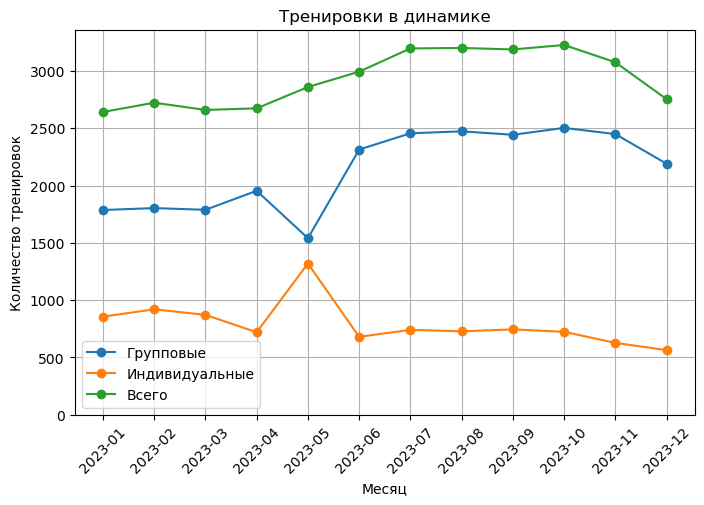

In [327]:
# динамика тренировок
plt.figure(figsize=(8,5))
plt.plot(p_gr['mon'],p_gr['cnt_group'],marker='o',label='Групповые')
plt.plot(p_gr['mon'],p_gr['cnt_indiv'],marker='o',label='Индивидуальные')
plt.plot(p_gr['mon'],p_gr['cnt_total'],marker='o',label='Всего')
plt.xlabel('Месяц')
plt.ylabel('Количество тренировок')
plt.title('Тренировки в динамике')
plt.legend()
plt.grid()
plt.ylim(bottom=0)
plt.xticks(rotation=45)
plt.show()

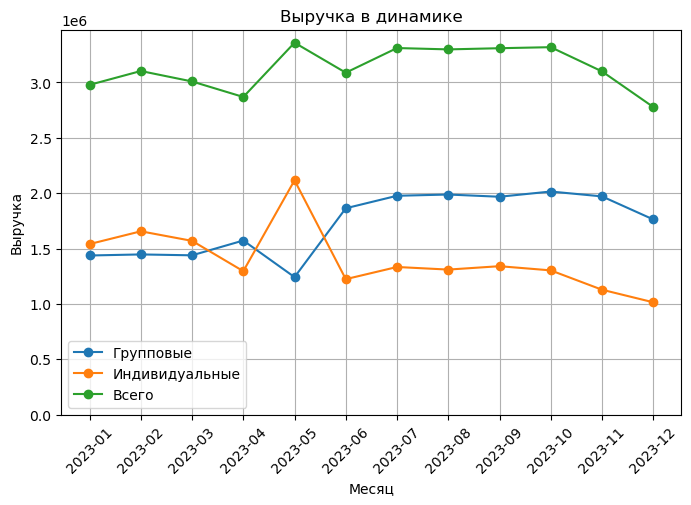

In [328]:
# динамика выручки
plt.figure(figsize=(8,5))
plt.plot(p_gr['mon'],p_gr['sum_group'],marker='o',label='Групповые')
plt.plot(p_gr['mon'],p_gr['sum_indiv'],marker='o',label='Индивидуальные')
plt.plot(p_gr['mon'],p_gr['sum_total'],marker='o',label='Всего')
plt.xlabel('Месяц')
plt.ylabel('Выручка')
plt.title('Выручка в динамике')
plt.legend()
plt.grid()
plt.ylim(bottom=0)
plt.xticks(rotation=45)
plt.show()

### Задача 4. Считаем LT и LTR

In [329]:
pivot_pay['min_mon'] = pivot_pay.groupby('id_user')['mon'].transform('min')
pivot_pay['max_mon'] = pivot_pay.groupby('id_user')['mon'].transform('max')
pivot_pay.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon
0,1000,2023-03,0,2,0.0,3600.0,2,3600.0,2023-03,2023-12
1,1000,2023-04,0,4,0.0,7200.0,4,7200.0,2023-03,2023-12
2,1000,2023-05,0,4,0.0,6400.0,4,6400.0,2023-03,2023-12
3,1000,2023-06,0,2,0.0,3600.0,2,3600.0,2023-03,2023-12
4,1000,2023-07,0,4,0.0,7200.0,4,7200.0,2023-03,2023-12


In [330]:
pay_ltr = pivot_pay.groupby('id_user').agg(ltr = ('sum_total','sum')).reset_index()
print(round(pay_ltr['ltr'].mean(),2))
print(round(pay_ltr['ltr'].median(),2))

38720.95
30600.0


<Axes: xlabel='ltr', ylabel='Count'>

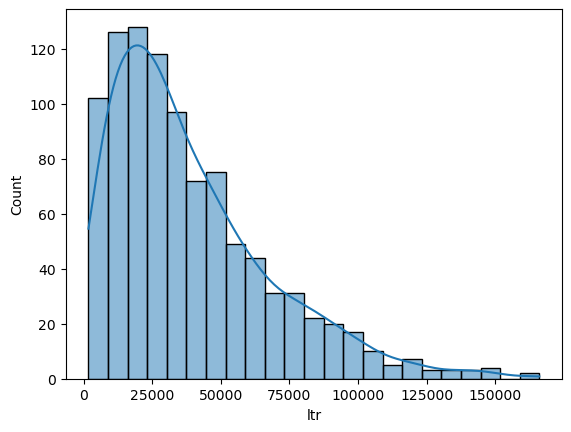

In [331]:
sns.histplot(pay_ltr['ltr'],kde = 'True')

In [332]:
clean_pay = pivot_pay[pivot_pay['max_mon'] != '2023-12']
print(len(pivot_pay))
print(len(clean_pay))

5293
2558


In [333]:
clean_ltr = clean_pay.groupby('id_user').agg(ltr = ('sum_total','sum')).reset_index()
print(round(clean_ltr['ltr'].mean(),2))
print(round(clean_ltr['ltr'].median(),2))

32637.21
25600.0


In [334]:
clean_pay2 = pivot_pay[pivot_pay['min_mon'].isin(['2023-01','2023-02','2023-03','2023-04'])]
print(len(clean_pay2))

4165


In [335]:
clean2_ltr = clean_pay2.groupby('id_user').agg(ltr = ('sum_total','sum')).reset_index()
print(round(clean2_ltr['ltr'].mean(),2))
print(round(clean2_ltr['ltr'].median(),2))

43927.63
36000.0


In [336]:
p_gr2 = clean_pay2.groupby('id_user').agg(nmon = ('id_user','count')).reset_index()
print(round(p_gr2['nmon'].mean(),2))
print(round(p_gr2['nmon'].median(),2))

6.25
7.0


### Задача 5. Анализ маркетинговой акции

In [337]:
cnt_ind_apr = p_gr.loc[p_gr['mon'] == '2023-04', 'cnt_indiv'].iloc[0]
cnt_gr_apr = p_gr.loc[p_gr['mon'] == '2023-04', 'cnt_group'].iloc[0]
cnt_ind_may = p_gr.loc[p_gr['mon'] == '2023-05', 'cnt_indiv'].iloc[0]
cnt_gr_may = p_gr.loc[p_gr['mon'] == '2023-05', 'cnt_group'].iloc[0]
cnt_ind_june = p_gr.loc[p_gr['mon'] == '2023-06', 'cnt_indiv'].iloc[0]
cnt_gr_june = p_gr.loc[p_gr['mon'] == '2023-06', 'cnt_group'].iloc[0]

In [338]:
# фактическая выручка за май
rev_fact_may = p_gr.loc[p_gr['mon'] == '2023-05', 'sum_total'].iloc[0]

In [339]:
# гипотетическая выручка за май
rev_hep_may = (cnt_ind_apr + cnt_ind_june)*0.5*1800 + (cnt_gr_apr + cnt_gr_june)*0.5*800

In [340]:
print(f'Фактическая выручка за май {rev_fact_may}')
print(f'Гипотетическая выручка за май {rev_hep_may}')
print(f'Прирост выручки из-за проведения акции {rev_fact_may-rev_hep_may}')

Фактическая выручка за май 3358800.0
Гипотетическая выручка за май 2968000.0
Прирост выручки из-за проведения акции 390800.0


In [341]:
# фактическая прибыль за май
profit_fact_may = p_gr.loc[p_gr['mon'] == '2023-05', 'cnt_indiv'].iloc[0]*(1600-800)+\
p_gr.loc[p_gr['mon'] == '2023-05', 'cnt_group'].iloc[0]*(800-200)

In [342]:
# гипотетическая прибыль за май
profit_hep_may = (cnt_ind_apr + cnt_ind_june)*0.5*(1800-800) + (cnt_gr_apr + cnt_gr_june)*0.5*(800-200)

In [343]:
print(f'Прирост прибыли из-за проведения акции {profit_fact_may-profit_hep_may}')

Прирост прибыли из-за проведения акции -400.0
